# Consensus vs LLM judges on fresh logic data (E2-A)

**Question.** Can a *gold-free* metric tell whether a candidate first-order-logic (FOL) formalization of an English
sentence is faithful to it? This artifact is the pre-registered confirmation test of the frozen **cross-family solver
consensus** score `c_score_align` (**V0**) on an untouched NL→FOL set (E2). V0 asks: *what share of peer
formalizations of the same sentence, written by models from other families, does z3 prove equivalent to the
candidate after predicate/constant alignment?* V0 = 1 − that share, so a high V0 means likely ERROR.

**What happened in the run.** 550 sentences × 10 systems = 5,500 candidates were generated and scored with every
label-free metric (V0, peer-text fusion, exact-symbol consensus, bag-of-words and z3 role checks, the user's pilot
structural metrics, and a local Qwen3-8B judge). All scores were sealed before any labels existed. The shared API
budget ran out, so a 2-LLM panel labelled only the first **110 sentences** (sha1 order; 37 long `L25`, 37
exception `EXC`, 36 `DT`). That prefix gives **273 labelled rows**.

**Headline (full artifact).** On DT, V0's stratified AUROC is 0.916, against 0.913 for a local 8B judge.
Consensus ties the small judge and adds nothing over it. The user's pilot structural metrics sit at chance (≈0.5).
V0 is **not rename-invariant**: correct formulas whose symbols are renamed to nonce words are flagged 100% of the time.

**What this notebook runs.** `method.py` is a stage orchestrator that shells out to GPU and paid-API scripts, so it
cannot run in Colab. The notebook keeps it verbatim and prints its stage plan. It then runs the artifact's **analysis
stage** on the sealed scores and labels in `mini_demo_data.json`. That is the code path of `audit/rederive.py` plus
the frozen `stats.py` bootstrap. Every score is oriented **higher = more likely ERROR**, and label 1 = ERROR.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages are needed (the analysis uses only numpy / scipy / sklearn / pandas / matplotlib).

# numpy, scipy, scikit-learn, pandas, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
# --- original method.py imports ---
import argparse
import os
import subprocess
import sys
from pathlib import Path

# --- original audit/rederive.py + frozen stats.py imports ---
import json, random, collections
from collections import defaultdict
import numpy as np
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score

# --- notebook additions (tables + plots) ---
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-5/experiment-11/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
EXAMPLES = data["datasets"][0]["examples"]
print(len(EXAMPLES), "sentences |", sum(len(e["rows"]) for e in EXAMPLES), "labelled candidate rows |",
      sum(len(e["rename_controls"]) for e in EXAMPLES), "rename-control rows")
ex0 = next(e for e in EXAMPLES if e["rows"])
print("example sentence:", ex0["input"])
for r in ex0["rows"][:3]:
    print(f"  [{r['label']:7s}] {r['candidate_fol']}")

100 sentences | 273 labelled candidate rows | 151 rename-control rows
example sentence: If Xiomara either wakes up at dawn or has light slumber (but not both), then she sleeps very lightly.
  [CORRECT] (WakesUpAt(xiomara, dawn) ⊕ Has(xiomara, lightSlumber)) → SleepsVeryLightly(xiomara)
  [CORRECT] (WakesAtDawn(xiomara) ⊕ HasLightSlumber(xiomara)) → SleepsVeryLightly(xiomara)
  [CORRECT] (WakesUpAt(xiomara, dawn) ⊕ LightSlumber(xiomara)) → SleepsVeryLightly(xiomara)


## Config

The tunable parameters. The original values are in the comments. `PREFIX` is `method.py`'s `--prefix`, the number of
sha1-order sentences whose panel labels are used. `B_BOOT` is the number of stratified sentence-cluster bootstrap
replicates behind every CI. `N_PLACEBO` is the number of shuffled-label placebo replicates in `audit/rederive.py`.

In [5]:
PREFIX = 110       # original: 110  (method.py --prefix; sentences of the sha1 order with panel labels)
B_BOOT = 2000      # original: 2000 (stratified sentence-cluster bootstrap replicates for 95% CIs)
N_PLACEBO = 200    # original: 200  (shuffled-within-stratum label placebo replicates)
SEED = 0           # original: 0

## 1. The pipeline: `method.py` stages (verbatim)

`method.py` runs these stages in order:
**l3 → consensus → pairwise → exact** (z3 scoring of every candidate against its peers) →
**prep → judges** (API LLM judges) → **local_judge** (Qwen3-8B on GPU) → **pilot** (the user's structural metrics) →
**assemble** (seal all label-free scores) → **labels:*** (build and seal panel/prover labels) → **join → analyse**
(meta-evaluation) → **rename** (rename-invariance controls) → **union** (E2-B rows) → **outputs**.

Only `WS` changes, because a notebook has no `__file__`. `main()` is kept as it was but **not called**: its stages need
the artifact's frozen code, a GPU environment and a paid OpenRouter key. The cell below prints the stage plan. The
cells after it re-run the *join / analyse / rename* logic on the sealed outputs of the earlier stages.

In [6]:
WS = Path.cwd()  # original: Path(__file__).resolve().parent
PY = str(WS / "env" / ".venv" / "bin" / "python")
GPU = "/root/e2a_gpu/.venv/bin/python"
E2PY = str(WS / "e2src" / ".venv" / "bin" / "python")


def stages(prefix: int) -> list[tuple[str, list[str], Path]]:
    s = [("l3", [PY, "scoring/score_consensus.py", "--stage", "l3"], WS),
         ("consensus", [PY, "scoring/score_consensus.py", "--stage", "score", "--workers", "30"], WS),
         ("pairwise", [PY, "scoring/score_consensus.py", "--stage", "pairwise", "--workers", "36"], WS),
         ("exact", [PY, "scoring/score_consensus.py", "--stage", "exact", "--workers", "36"], WS),
         ("prep", [PY, "scoring/api_judges.py", "--stage", "prep", "--workers", "10"], WS),
         ("judges", [PY, "scoring/api_judges.py", "--stage", "judges", "--concurrency", "32"], WS),
         ("local_judge", [GPU, "scoring/local_judge.py", "--which", "qwen8b_disg,qwen8b_orig", "--bs", "64"], WS),
         ("pilot", [PY, "scoring/pilot_metrics_E2.py"], WS),
         ("assemble", [PY, "scoring/assemble_scores.py"], WS)]
    s += [(f"labels:{x}", [E2PY, f"src_e2/{x}.py"], WS / "e2src")
          for x in ("assemble_e2", "controls_e2", "testability_e2", "seal_e2", "verify_seal")]
    s += [("join", [PY, "analysis/analyse_E2A.py", "--stage", "join"], WS),
          ("analyse", [PY, "analysis/analyse_E2A.py", "--stage", "analyse"] + (["--prefix", str(prefix)] if prefix else []), WS),
          ("rename", [PY, "analysis/rename_V0.py"], WS),
          ("union", [PY, "analysis/union_E2B.py", "--deadline-utc", "2026-09-24T15:40:00Z", "--once"], WS),
          ("outputs", [PY, "analysis/make_outputs.py"], WS)]
    return s


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--from", dest="start", default="l3")
    ap.add_argument("--prefix", type=int, default=110)
    a = ap.parse_args()
    env = dict(os.environ, PYTHONHASHSEED="0", OPENBLAS_NUM_THREADS="1", OMP_NUM_THREADS="1")
    run = False
    for name, cmd, cwd in stages(a.prefix):
        run = run or name.startswith(a.start)
        if run:
            print(f"== {name}: {' '.join(cmd)}", flush=True)
            subprocess.run(cmd, cwd=cwd, env=env, check=True)


# Notebook: print the plan instead of executing it (main() would shell out to GPU / paid-API scripts).
for name, cmd, cwd in stages(PREFIX):
    print(f"== {name:24s} {' '.join(Path(c).name if c.startswith('/') else c for c in cmd)}")

== l3                       python scoring/score_consensus.py --stage l3
== consensus                python scoring/score_consensus.py --stage score --workers 30
== pairwise                 python scoring/score_consensus.py --stage pairwise --workers 36
== exact                    python scoring/score_consensus.py --stage exact --workers 36
== prep                     python scoring/api_judges.py --stage prep --workers 10
== judges                   python scoring/api_judges.py --stage judges --concurrency 32
== local_judge              python scoring/local_judge.py --which qwen8b_disg,qwen8b_orig --bs 64
== pilot                    python scoring/pilot_metrics_E2.py
== assemble                 python scoring/assemble_scores.py
== labels:assemble_e2       python src_e2/assemble_e2.py
== labels:controls_e2       python src_e2/controls_e2.py
== labels:testability_e2    python src_e2/testability_e2.py
== labels:seal_e2           python src_e2/seal_e2.py
== labels:verify_seal       python 

## 2. Statistics: stratified AUROC and the sentence-cluster bootstrap

These functions are copied from the artifact's frozen `eval2/src/stats.py` and from `analysis/analyse_E2A.py`
(`strat_boot_weights`).

- **Stratified AUROC** is a within-stratum pair AUROC: the chance that a random ERROR row outscores a random CORRECT row
  *of the same stratum*. Strata are weighted by n_err × n_cor. This prevents stratum base rates from inflating the
  score.
- **Bootstrap.** Within each stratum, *sentences* are resampled with replacement. All candidate rows of a sentence move
  together, because rows of one sentence share peers and are not independent. Each replicate becomes a row-weight
  vector, and `WStratAuc` evaluates the AUROC under those weights.

In [7]:
def auc(y, s) -> float:
    """Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score)."""
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auc(y, s, strata) -> float:
    """Within-stratum pair AUROC: sum_s w_s AUROC_s with w_s = n_err,s * n_cor,s (exp 5 'stratified')."""
    y, s, strata = np.asarray(y, float), np.asarray(s, float), np.asarray(strata)
    num = den = 0.0
    for st in np.unique(strata):
        m = strata == st
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def ci(vals, lo=2.5, hi=97.5):
    v = np.asarray([x for x in vals if x is not None and not np.isnan(x)], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


# ------------------------------------------------------------------ weighted (bootstrap-count) statistics
class WAuc:
    """AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once."""

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class WStratAuc:
    """Within-stratum pair AUROC under row weights."""

    def __init__(self, y, s, strata):
        self.y = np.asarray(y, float)
        strata = np.asarray(strata)
        self.parts = [(np.where(strata == st)[0], WAuc(self.y[strata == st], np.asarray(s, float)[strata == st]))
                      for st in np.unique(strata)]

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        num = den = 0.0
        for ix, wa in self.parts:
            ww = w[ix]
            n1 = (ww * self.y[ix]).sum()
            n0 = (ww * (1 - self.y[ix])).sum()
            if n1 > 0 and n0 > 0:
                num += wa(ww) * n1 * n0
                den += n1 * n0
        return num / den if den else float("nan")


def strat_boot_weights(sids, strata, b: int = B_BOOT, seed: int = 0) -> np.ndarray:
    """Stratified sentence-cluster bootstrap: within each stratum, sentences resampled with replacement.
    -> (B, n_rows) multiplicity weights."""
    sids, strata = np.asarray(sids), np.asarray(strata)
    rng = np.random.default_rng(seed)
    W = np.zeros((b, len(sids)))
    for st in sorted(set(strata)):
        m = strata == st
        keys, inv = np.unique(sids[m], return_inverse=True)
        S = len(keys)
        C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        W[:, np.where(m)[0]] = C[:, inv]
    return W

## 3. Join sealed scores with labels (`join` stage, as in `audit/rederive.py`)

This mirrors `audit/rederive.py`. The original read the sealed label file, the candidates, the consensus cache, the
local-judge cache and the pilot cache, and joined them on `row_key`. In the demo data that join is already done per
sentence. A row enters the meta-evaluation only if it meets all of these conditions:

1. Its sentence is in the first `PREFIX` sentences.
2. Its label is `CORRECT` or `ERROR`.
3. It is not a "reading choice" (an ambiguous sentence).
4. Its label tier is `A` or `B`.

The score columns are:
- `v0`: the frozen cross-family consensus `c_score_align`.
- `loc`: the local Qwen3-8B judge on the *disguised* view, computed as 1 − P(faithful).
- `pilot_*`: the user's structural pilot metrics.
- A few extra frozen scores for the plot: `p_peer_text` (PT fusion), `c_exact` (consensus without an aligner),
  `l2_bow` and `l3_z3` (text-side checks).

In [8]:
PM = ("pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_rerun_jacc")
EXTRA = ("p_peer_text", "c_exact", "l2_bow", "l3_z3", "judge_local_qwen8b_orig")
keep = set(e["metadata_sentence_id"] for e in EXAMPLES[:PREFIX])  # original: e2a_order.json[:110]
rows = []
for e in EXAMPLES:
    for l in e["rows"]:
        if e["metadata_sentence_id"] not in keep or l["label"] not in ("CORRECT", "ERROR") or l["label_tier"] not in ("A", "B"):
            continue
        rows.append(dict(k=l["row_key"], sid=e["metadata_sentence_id"], st=e["metadata_stratum"], y=int(l["label"] == "ERROR"),
                         v0=l["v0"], loc=l["loc"], words=e["metadata_words"], **{m: l.get(m) for m in PM + EXTRA}))
df = pd.DataFrame(rows)
print(len(rows), "rows;", df.groupby("st").y.agg(n="size", n_err="sum").T.to_string())
df.head()

273 rows; st      DT  EXC  L25
n      179   52   42
n_err   74   41   35


,k,sid,st,y,v0,loc,words,pilot_joint_conflict,pilot_arity_incons,pilot_shape_incons,pilot_dangling,pilot_rerun_jacc,p_peer_text,c_exact,l2_bow,l3_z3,judge_local_qwen8b_orig
0,62b8d8e91effd650|fewshot_v1,b91115ec794d,DT,0,0.375000,0.05,19,0,0,0,1.000000,0.294268,0.354247,0.750000,0.000,0.750000,0.05
1,bc7ebbda34033f05|fewshot_v1,b91115ec794d,DT,0,1.000000,0.00,19,0,0,0,1.000000,0.332716,0.938109,1.000000,0.125,0.583333,0.00
2,781e1b6e32dd037e|fewshot_v1,b91115ec794d,DT,0,0.444444,0.05,19,0,0,0,1.000000,0.313692,0.342394,1.000000,0.000,0.583333,0.00
3,ac4a0e43dcfc6e8c|fewshot_v1,b91115ec794d,DT,0,0.444444,0.05,19,0,0,1,0.833333,0.294268,0.420381,0.777778,0.000,0.750000,0.05
4,0fb444c5049ce4b4|fewshot_v1,b91115ec794d,DT,0,0.500000,0.05,19,0,0,0,1.000000,0.381514,0.471281,1.000000,0.000,0.750000,0.05


## 4. `analyse`: stratified AUROC per cell

Three cells are analysed:
- **ALL** combines the three strata.
- **DT** rows have prover-built gold.
- **LONG** combines L25 and EXC, the long and heavily conditioned sentences the user cares most about.

The pre-registered testability bar was ≥50 ERROR and ≥50 CORRECT rows. **LONG misses it**, with only 18 CORRECT rows,
so the LONG hypotheses are *NOT_TESTABLE*. Its numbers are descriptive only.

In [9]:
def sauc(rs, col, ycol="y"):
    num = den = 0
    for st in set(r["st"] for r in rs):
        g = [r for r in rs if r["st"] == st and r[col] is not None]
        y = [r[ycol] for r in g]
        if 0 < sum(y) < len(y):
            w = sum(y) * (len(y) - sum(y))
            num += roc_auc_score(y, [r[col] for r in g]) * w
            den += w
    return num / den if den else None


out = {}
for cell, sts in (("ALL", ("L25", "EXC", "DT")), ("DT", ("DT",)), ("LONG", ("L25", "EXC"))):
    rs = [r for r in rows if r["st"] in sts]
    out[cell] = {"n": len(rs), "n_err": sum(r["y"] for r in rs), "n_cor": sum(1 - r["y"] for r in rs),
                 "V0": sauc(rs, "v0"), "local_disg": sauc(rs, "loc")}
    out[cell]["delta_V0_minus_local"] = out[cell]["V0"] - out[cell]["local_disg"]
    for m in ("pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_rerun_jacc"):
        out[cell][m] = sauc(rs, m)
    for m in EXTRA:  # notebook addition: the other frozen label-free scores
        out[cell][m] = sauc(rs, m)
    out[cell]["testable_50_50"] = out[cell]["n_err"] >= 50 and out[cell]["n_cor"] >= 50
pd.DataFrame(out).T.round(3)

,n,n_err,n_cor,V0,local_disg,delta_V0_minus_local,pilot_joint_conflict,pilot_arity_incons,pilot_shape_incons,pilot_dangling,pilot_rerun_jacc,p_peer_text,c_exact,l2_bow,l3_z3,judge_local_qwen8b_orig,testable_50_50
ALL,273,150,123,0.890444,0.894992,-0.004548,0.5,0.506615,0.509981,0.413123,0.712615,0.901665,0.830912,0.751181,0.583274,0.900898,True
DT,179,74,105,0.916152,0.912934,0.003218,0.5,0.506757,0.509974,0.399614,0.7287,0.919369,0.854054,0.759974,0.572265,0.917632,True
LONG,94,76,18,0.603448,0.694684,-0.091236,0.5,0.505029,0.510057,0.563937,0.533046,0.704023,0.572557,0.653017,0.706178,0.71408,False


## 5. Bootstrap CIs: is consensus better than a small local judge?

This follows `lib/nl2fol_metrics.evaluate`: stratified AUROC with a stratified sentence-cluster bootstrap 95% CI, run
here for V0, the local judge and their paired difference. The same resamples feed both scores. A CI for
V0 − local that contains 0 means consensus shows no demonstrated advantage over an 8B judge.

In [10]:
boot = {}
for cell, sts in (("ALL", ("L25", "EXC", "DT")), ("DT", ("DT",)), ("LONG", ("L25", "EXC"))):
    g = df[df.st.isin(sts) & df.v0.notna() & df["loc"].notna()]
    y, st, sid = g.y.values, g.st.values, g.sid.values
    W = strat_boot_weights(sid, st, B_BOOT, SEED)
    fv, fl = WStratAuc(y, g.v0.values, st), WStratAuc(y, g["loc"].values, st)
    bv = np.array([fv(W[i]) for i in range(B_BOOT)]); bl = np.array([fl(W[i]) for i in range(B_BOOT)])
    boot[cell] = {"n": len(g), "V0": strat_auc(y, g.v0.values, st), "V0_ci": ci(bv),
                  "local": strat_auc(y, g["loc"].values, st), "local_ci": ci(bl),
                  "delta": strat_auc(y, g.v0.values, st) - strat_auc(y, g["loc"].values, st), "delta_ci": ci(bv - bl)}
for c, b in boot.items():
    print(f"{c:5s} n={b['n']:3d}  V0 {b['V0']:.3f} [{b['V0_ci'][0]:.3f},{b['V0_ci'][1]:.3f}]  "
          f"local {b['local']:.3f} [{b['local_ci'][0]:.3f},{b['local_ci'][1]:.3f}]  "
          f"V0-local {b['delta']:+.3f} [{b['delta_ci'][0]:+.3f},{b['delta_ci'][1]:+.3f}]")

ALL   n=273  V0 0.890 [0.838,0.940]  local 0.895 [0.844,0.938]  V0-local -0.005 [-0.047,+0.041]
DT    n=179  V0 0.916 [0.858,0.970]  local 0.913 [0.858,0.958]  V0-local +0.003 [-0.042,+0.052]
LONG  n= 94  V0 0.603 [0.463,0.735]  local 0.695 [0.551,0.837]  V0-local -0.091 [-0.219,+0.017]


## 6. Placebo: shuffle labels within strata

This is a sanity check on the pipeline. When labels are permuted within each stratum, every AUROC should collapse to
about 0.5 and V0 − local to about 0. If the real V0 AUROC sits above the placebo's 97.5th percentile, the signal is not
an artefact of stratification or ties.

In [11]:
rng = random.Random(0)
pl = []
for b in range(N_PLACEBO):
    rs = [dict(r) for r in rows]
    for st in set(r["st"] for r in rs):
        idx = [i for i, r in enumerate(rs) if r["st"] == st]
        ys = [rs[i]["y"] for i in idx]
        rng.shuffle(ys)
        for i, y in zip(idx, ys):
            rs[i]["y"] = y
    pl.append((sauc(rs, "v0"), sauc(rs, "v0") - sauc(rs, "loc")))
pa = np.array(pl)
out["placebo_shuffled"] = {"V0_mean": float(pa[:, 0].mean()), "V0_p2.5_97.5": np.percentile(pa[:, 0], [2.5, 97.5]).tolist(),
                           "delta_mean": float(pa[:, 1].mean()), "delta_p2.5_97.5": np.percentile(pa[:, 1], [2.5, 97.5]).tolist(),
                           "real_V0_ALL_above_placebo_p97.5": bool(out["ALL"]["V0"] > np.percentile(pa[:, 0], 97.5))}
out["placebo_shuffled"]

{'V0_mean': 0.49249143633356957,
 'V0_p2.5_97.5': [0.4210651429246397, 0.5601715686274511],
 'delta_mean': -0.0006115639026695069,
 'delta_p2.5_97.5': [-0.06891536735175995, 0.06764410583510504],
 'real_V0_ALL_above_placebo_p97.5': True}

## 7. `rename`: is V0 invariant to meaning-preserving renaming?

This follows `analysis/rename_V0.py`. The controls take a candidate and rewrite its predicate and constant names,
either with **synonyms** (`RENAME_SYN`) or with **nonce words** (`RENAME_NONCE`). The logic is unchanged, and V0 is
recomputed against the untouched peers. **FA** is the share of controls that V0 flags (V0 > 0.5). **base** is the
flag rate of the original parents. An invariant metric would have FA ≈ base. Here FA is far higher, because V0's
vocabulary aligner cannot match unrelated names, so V0 rewards agreeing with the peers' wording.

In [12]:
rr = [r for e in EXAMPLES for r in e["rename_controls"]]
for t in ("RENAME_SYN", "RENAME_NONCE"):
    g = [r for r in rr if r["type"] == t and r["v0_control"] is not None and r["v0_parent"] is not None]
    out[t] = {"n": len(g), "FA": sum(r["v0_control"] > 0.5 for r in g) / len(g), "base": sum(r["v0_parent"] > 0.5 for r in g) / len(g)}
# drift gate + spend come from raw logs in the original (e2src/panel_drift_E2.json, cost ledgers); stored in data metadata
out["drift_majority_agreement"] = data["metadata"]["drift_majority_agreement"]
out["spend_usd"] = data["metadata"]["spend_usd"]
{k: out[k] for k in ("RENAME_SYN", "RENAME_NONCE", "drift_majority_agreement", "spend_usd")}

{'RENAME_SYN': {'n': 28, 'FA': 1.0, 'base': 0.25},
 'RENAME_NONCE': {'n': 123, 'FA': 1.0, 'base': 0.17886178861788618},
 'drift_majority_agreement': 0.9554,
 'spend_usd': 2.04500803205}

## 8. Results

**Comparison with the full artifact.** The `reference_full_run` values come from the artifact's `audit/rederive_out.json`.
The demo data holds every labelled row of the prefix, so the AUROC cells should match exactly. It holds 100 of 110
sentences, so the rename controls are a subset of the original 181.

**Plots.**
- **Left:** stratified AUROC per metric on ALL and DT. The dashed line at 0.5 is chance, and the error bars are V0 and
  local-judge bootstrap CIs.
- **Right:** the rename-control false-alarm rate against the parents' base rate.

        cell               metric  notebook  full artifact
         ALL                    n   273.000        273.000
         ALL                   V0     0.890          0.890
         ALL           local_disg     0.895          0.895
         ALL delta_V0_minus_local    -0.005         -0.005
         ALL     pilot_rerun_jacc     0.713          0.713
         ALL       pilot_dangling     0.413          0.413
          DT                    n   179.000        179.000
          DT                   V0     0.916          0.916
          DT           local_disg     0.913          0.913
          DT delta_V0_minus_local     0.003          0.003
          DT     pilot_rerun_jacc     0.729          0.729
          DT       pilot_dangling     0.400          0.400
        LONG                    n    94.000         94.000
        LONG                   V0     0.603          0.603
        LONG           local_disg     0.695          0.695
        LONG delta_V0_minus_local    -0.091         -0.0

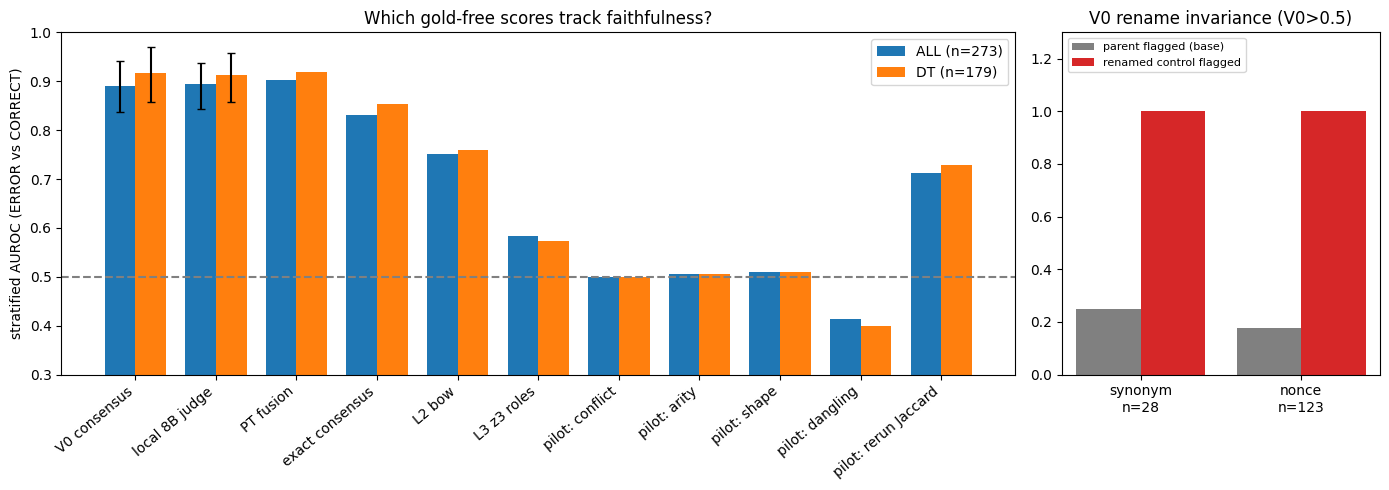

In [13]:
ref = data["metadata"]["reference_full_run"]
cmp_rows = []
for cell in ("ALL", "DT", "LONG"):
    for m in ("n", "V0", "local_disg", "delta_V0_minus_local", "pilot_rerun_jacc", "pilot_dangling"):
        cmp_rows.append({"cell": cell, "metric": m, "notebook": out[cell][m], "full artifact": ref[cell][m]})
for t in ("RENAME_SYN", "RENAME_NONCE"):
    for m in ("n", "FA", "base"):
        cmp_rows.append({"cell": t, "metric": m, "notebook": out[t][m], "full artifact": ref[t][m]})
print(pd.DataFrame(cmp_rows).round(3).to_string(index=False))

names = {"V0": "V0 consensus", "local_disg": "local 8B judge", "p_peer_text": "PT fusion", "c_exact": "exact consensus",
         "l2_bow": "L2 bow", "l3_z3": "L3 z3 roles", "pilot_joint_conflict": "pilot: conflict", "pilot_arity_incons": "pilot: arity",
         "pilot_shape_incons": "pilot: shape", "pilot_dangling": "pilot: dangling", "pilot_rerun_jacc": "pilot: rerun Jaccard"}
keys = ["V0", "local_disg", "p_peer_text", "c_exact", "l2_bow", "l3_z3"] + list(PM)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 1]})
x = np.arange(len(keys)); wd = 0.38
for j, (cell, col) in enumerate((("ALL", "tab:blue"), ("DT", "tab:orange"))):
    vals = [out[cell][k] if out[cell][k] is not None else np.nan for k in keys]
    a1.bar(x + (j - 0.5) * wd, vals, wd, color=col, label=f"{cell} (n={out[cell]['n']})")
    for i, (k, bk) in enumerate((("V0", "V0"), ("local_disg", "local"))):
        lo, hi = boot[cell][bk + "_ci"]
        a1.errorbar(i + (j - 0.5) * wd, boot[cell][bk], yerr=[[boot[cell][bk] - lo], [hi - boot[cell][bk]]], color="k", capsize=3)
a1.axhline(0.5, ls="--", c="gray"); a1.set_ylim(0.3, 1.0)
a1.set_xticks(x); a1.set_xticklabels([names[k] for k in keys], rotation=40, ha="right")
a1.set_ylabel("stratified AUROC (ERROR vs CORRECT)"); a1.set_title("Which gold-free scores track faithfulness?"); a1.legend()
t = ["RENAME_SYN", "RENAME_NONCE"]
a2.bar(np.arange(2) - 0.2, [out[k]["base"] for k in t], 0.4, color="gray", label="parent flagged (base)")
a2.bar(np.arange(2) + 0.2, [out[k]["FA"] for k in t], 0.4, color="tab:red", label="renamed control flagged")
a2.set_xticks(range(2)); a2.set_xticklabels([f"synonym\nn={out['RENAME_SYN']['n']}", f"nonce\nn={out['RENAME_NONCE']['n']}"])
a2.set_ylim(0, 1.3); a2.set_title("V0 rename invariance (V0>0.5)"); a2.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

**Reading the results**

- **Consensus works about as well as a small judge, and no better.** On DT, V0 ≈ 0.92 and the local 8B judge ≈ 0.91.
  The paired-delta CI contains 0, so the extra peer generations and z3 calls buy no measurable gain over an 8B judge.
- **The pilot structural metrics do not track correctness.** Joint conflict, arity and shape consistency all sit at
  ≈0.5, and dangling predicates falls below 0.5. Only rerun-Jaccard is above chance (≈0.71), and it is a lexical
  agreement proxy.
- **V0 is not rename-invariant.** Correct formulas with renamed symbols are flagged almost every time. The score
  measures agreement with the peers' vocabulary as much as meaning.
- **Long, heavily conditioned sentences (LONG) are not testable on this prefix.** With only 18 CORRECT rows, V0 falls
  to about 0.60 there, and the budget stop left too few labels for a confirmatory test.